# Einleitung

Dieses Projekt analysiert globale Wildfires anhand satellitenbasierter Daten des NASA FIRMS Systems.
Der Fokus liegt auf der Untersuchung räumlicher Muster und der Intensität von Wildfires innerhalb eines kurzen Zeitraums (letzte 24 Stunden).

Der Datensatz enthält georeferenzierte Punktdaten, wobei jede Zeile ein detektiertes Wildfire repräsentiert.
Wichtige Variablen wie die geografische Lage (Latitude/Longitude), die Detektionssicherheit (confidence) sowie die Feuerintensität (Fire Radiative Power, FRP) werden genutzt, um die Verteilung und Eigenschaften der Brände zu analysieren.

Das Ziel dieses Projekts ist es, eine automatisierte Pipeline zu entwickeln, die Wildfires verarbeitet, relevante Informationen herausfiltert, eine gezielte Analyse ermöglicht und die Ergebnisse übersichtlich auf einer interaktiven Karte visualisiert.

Die Forschungsfrage, die mit diesem Projekt beantwortet werden soll, ist: *Wo befinden sich die intensivsten und zuverlässig detektierten Wildfires weltweit innerhalb der letzten 24 Stunden?*

Als Leitfragen zur Beantwortung der Forschungsfrage dienen:
1. **Intensität**: Wo traten die stärksten Wildfires (höchste Fire Radiative Power) auf?
2. **Räumliche Analyse**: Sind die stärksten Wildfires in bestimmten Regionen der Welt konzentriert? Wo kommen Wildfires global betrachtet vor?
3. **Zeitliche Analyse**: Wie viele Wildfires wurden im betrachteten Zeitraum detektiert?
4. **Datenqualität**: Wie verteilt sich die Detektionssicherheit (confidence) über die erfassten Wildfires?

### Schritt 1: Importe, Paths & Überblick verschaffen

In [142]:
#Importe
from pathlib import Path
import pandas as pd
import geopandas as gpd
from scripts.spatial_tools import reverse_geocode_coordinates #Import meiner eigenen geocoder Funktion
import matplotlib.pyplot as plt


#Pfade
data_dir = Path("../data") #heisst "gehe eine Orderstruktur höher" und dann in "data"
raw_dir = data_dir / "raw" #wo der Rohdatenordner zu finden ist
processed_dir = data_dir / "processed" #wo der Ordner mit den verarbeiteten Rohdaten ist
csv_path = raw_dir / "SUOMI_VIIRS_C2_Global_24h.csv" #wo das CSV abgelget ist

#Rohdaten laden
df = pd.read_csv(csv_path)


In [143]:
#Inhalte anzeigen & Überblick verschaffen
print(df.head())
print() #Zeilenumbruch
print(df.info())
print() #Zeilenumbruch

   latitude  longitude  bright_ti4  scan  track    acq_date  acq_time  \
0 -18.35942   26.65817      302.52  0.44   0.46  2026-05-18         1   
1 -18.35993   26.66234      309.22  0.44   0.46  2026-05-18         1   
2 -18.36387   26.45063      332.84  0.43   0.46  2026-05-18         1   
3 -18.36698   26.47523      320.07  0.43   0.46  2026-05-18         1   
4 -18.36750   26.47932      321.52  0.43   0.46  2026-05-18         1   

  satellite confidence version  bright_ti5   frp daynight  
0         N    nominal  2.0NRT      289.85  1.19        N  
1         N    nominal  2.0NRT      289.42  1.53        N  
2         N    nominal  2.0NRT      292.60  4.09        N  
3         N    nominal  2.0NRT      292.31  2.85        N  
4         N    nominal  2.0NRT      291.41  2.85        N  

<class 'pandas.DataFrame'>
RangeIndex: 39787 entries, 0 to 39786
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   latitude    397

**Zusammenfassung Schritt 1:** _data.head()_ hat uns die ersten 5 Reihen ausgegeben. Daraus können wir ableiten, dass für die Forschungsfrage lediglich die Spalten "latitude", "longitude", "acq_date", "confidence" und "frp" relevant sind. Daher selektieren wir diese in Schritt 2. Die Header sollten ausserdem noch etwas verständlicher unbenannt werden. Dafür stütze ich mich auf die Informationen im User Guide, der unter den Rohdaten abgelegt ist. Zudem hat und _data.info()_ gezeigt, dass acq_date momentan noch ein String ist. Das müssen wir ebenfalls ändern.

### Schritt 2: Bereinigung der Rohdaten

In [144]:
relevant_data = df[["latitude", "longitude", "acq_date", "confidence", "frp"]].copy() #relevante Spalten auswählen und eine echte Kopie herstellen vom original dataframe
print() #Zeilenumbruch
print(relevant_data.head()) #reduzierter Dataframe anzeigen
print() #Zeilenumbruch
print(relevant_data.isna().sum()) #überprüfen, ob fehlende Werte (NaN) bestehen
print() #Zeilenumbruch

#Header (Spaltenbezeichnunge) unbenennen:
relevant_data = relevant_data.rename(columns={
    "latitude": "lat",
    "longitude": "lon",
    "acq_date": "detection_date",
    "confidence": "detection_confidence",
    "frp": "fire_radiative_power"
})

print(relevant_data.head()) #neue Header anzeigen lassen resp. erste 5 Zeilen
print() #Zeilenumbruch

relevant_data["detection_date"] = pd.to_datetime(relevant_data["detection_date"]) #detection_date von string in ein Datum umwandeln
print(relevant_data.info()) #schauen ob der string erfolgreich umgewandelt wurde
print() #Zeilenumbruch




   latitude  longitude    acq_date confidence   frp
0 -18.35942   26.65817  2026-05-18    nominal  1.19
1 -18.35993   26.66234  2026-05-18    nominal  1.53
2 -18.36387   26.45063  2026-05-18    nominal  4.09
3 -18.36698   26.47523  2026-05-18    nominal  2.85
4 -18.36750   26.47932  2026-05-18    nominal  2.85

latitude      0
longitude     0
acq_date      0
confidence    0
frp           0
dtype: int64

        lat       lon detection_date detection_confidence  \
0 -18.35942  26.65817     2026-05-18              nominal   
1 -18.35993  26.66234     2026-05-18              nominal   
2 -18.36387  26.45063     2026-05-18              nominal   
3 -18.36698  26.47523     2026-05-18              nominal   
4 -18.36750  26.47932     2026-05-18              nominal   

   fire_radiative_power  
0                  1.19  
1                  1.53  
2                  4.09  
3                  2.85  
4                  2.85  

<class 'pandas.DataFrame'>
RangeIndex: 39787 entries, 0 to 39786
Dat

**Zusammenfassung Schritt 2:**
Wir machen von unserer Selektion des ursprünglichen Dataframes eine Kopie, um Komplikationen bei späteren Modifikationen an unserem Subset zu verhindern. *relevant_data.isna().sum()* hat ergeben, dass es bei unserem Datensatz keine fehlenden Werte gibt. Daher müssen wir an dieser Stelle nichts bereinigen. Das _detection_date_, das bisher noch als string erfasst war wurde jetzt in ein Datum umegwandelt.

Gemäss User Guide sind die Header wie folgt zu interpretieren:
* detection_date = YYYYMMDD Erfassungsdatum in year (YYYY), month (MM) and day (DD)
* detection_confidence =  Branderkennungs-Konfidenz (“L”=low, “N”=nominal, “H”=high)
* fire_radiative_power Strahlungsleistung des Feuers in megawatt (Mass für thermische Intensität)

## Schritt 3: Datenanalyse

##### 3.1. Statistische Übersicht der Feuerintensitäten (FRP)

In [145]:
print("Die statistische Übersicht der Feuerintensität (FRP) der letzten 24h:")
print(relevant_data["fire_radiative_power"].describe())

Die statistische Übersicht der Feuerintensität (FRP) der letzten 24h:
count    39787.000000
mean         8.052962
std         13.075523
min          0.000000
25%          2.630000
50%          4.730000
75%          8.460000
max        601.150000
Name: fire_radiative_power, dtype: float64


**Zusammenfassung Schritt 3.1.:** Die statistische Übersicht _(.describe())_ zeigt uns, dass es in den letzten 24h insgesamt 39787 Brandereignisse _(count)_ Weltweit gab. Davon weisen die meisten Waldbrände eine geringe Intensität (Werte in megawatt (MW)) auf. Der Median liegt bei 4.73 MW (Wert bei 50%), während der Durchschnitt (mean) durch wenige sehr starke Brände erhöht wird. Der hohe Maximalwert von 601.15 MW sowie die grosse Streuung (std) deuten auf einzelne extreme Ereignisse hin, während der Grossteil der Brände eher schwach ist.

##### 3.2. Histogramm: Verteilung der Feuerintensität

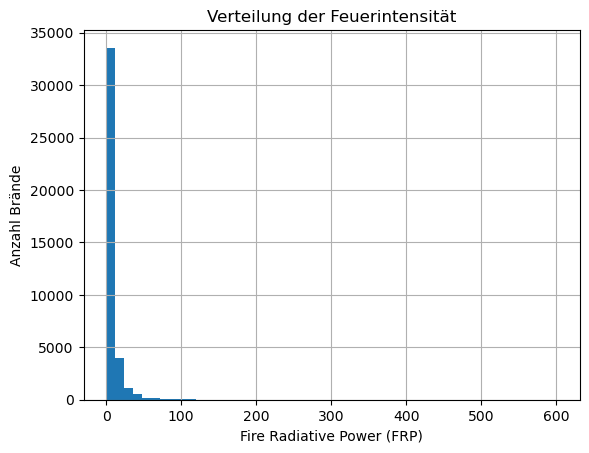

In [146]:
relevant_data["fire_radiative_power"].hist(bins=50)

plt.xlabel("Fire Radiative Power (FRP)")
plt.ylabel("Anzahl Brände")
plt.title("Verteilung der Feuerintensität")
plt.show()

**Zusammenfassung Schritt 3.2**: Das Histogramm der Feuerintensität visualisiert die Ergebnisse der statistischen Übersicht aus Abschnitt 3.1. Es zeigt deutlich, dass die Mehrheit der Wildfires eine geringe Fire Radiative Power (FRP) aufweist, während nur wenige Ereignisse sehr hohe Intensitätswerte erreichen. Diese rechtsschiefe Verteilung bestätigt die zuvor berechneten Kennzahlen, insbesondere den niedrigen Median im Vergleich zum Maximum, und verdeutlicht das Vorhandensein von Ausreissern mit sehr hoher Intensität.

##### 3.3. Detektionskonfidenz

In [152]:
print("\n Konfidenzelevels detektierten Brandereignisse:")
print(relevant_data["detection_confidence"].value_counts()) #Zählung der Werte pro Konfidenzlevel


 Konfidenzelevels detektierten Brandereignisse:
detection_confidence
nominal    34156
low         3909
high        1722
Name: count, dtype: int64


**Zusammenfassung Schritt 3.3:** Die meisten Wildfires wurden mit einem nominalen Konfidenzlevel detektiert. Nur wenige Ereignisse weisen ein niedriges oder hohes Konfidenzniveau auf. Insgesamt deutet dies auf eine überwiegend zuverlässige Datengrundlage hin.

##### 3.4. Die 20 stärksten Brandereignisse und deren geografische Lokation

In [147]:
strongest_wildfires = relevant_data.sort_values("fire_radiative_power", ascending = False).head(20).copy() #.copy(), weil der reduzierte df weiterverwendet wird

strongest_wildfires["country"] = reverse_geocode_coordinates(strongest_wildfires["lat"].astype(str) + ", " + strongest_wildfires["lon"].astype(str))

strongest_wildfires["country"] = strongest_wildfires["country"].str.split(",").str[-1].str.strip()


In [148]:
print("Die 20 stärksten Brandereignisse nach Land:")
print(strongest_wildfires["country"].value_counts())

print("\n Die 20 stärksten Brandereignisse nach Intensität:")
print(strongest_wildfires[["country", "fire_radiative_power"]])


Die 20 stärksten Brandereignisse nach Land:
country
United States                       6
Россия                              5
South Africa                        4
République démocratique du Congo    2
Belize                              1
México                              1
Venezuela                           1
Name: count, dtype: int64

 Die 20 stärksten Brandereignisse nach Intensität:
                                country  fire_radiative_power
15860                            Россия                601.15
24051                     United States                415.89
15870                            Россия                359.15
24063                     United States                307.38
20060                            Belize                257.76
24069                     United States                254.54
19677                            México                240.37
7508                       South Africa                237.08
24071                     United States       

**Zusammenfassung Schritt 3.4.:** Die Analyse der 20 stärksten Waldbrandereignisse _(.head(20))_ zeigt, dass besonders viele _(.value_counts())_ intensive Brände _(ascending = False)_ in den Vereinigten Staaten und in Russland registriert wurden. Die höchste gemessene Feuerintensität trat dabei in Russland mit einer Fire Radiative Power (FRP) von über 600 MW auf. Auch die Vereinigten Staaten weisen mehrere sehr starke Ereignisse mit hohen FRP-Werten auf. Die Ergebnisse deuten darauf hin, dass sich die intensivsten Waldbrände innerhalb des untersuchten 24-Stunden-Zeitraums räumlich auf wenige Regionen _(.value_counts())_ konzentrierten. Da die FRP den Energieausstoß eines Feuers beschreibt, weisen hohe Werte auf besonders intensive und energiereiche Brände hin.

### Schritt 4: Umwandlung GeoDataFrame und Erstellung interkative Karte

##### 4.1. Umwandlung DataFrame in GeoDataFrame mit aktiver Geometrie


In [149]:
wildfires_gdf = gpd.GeoDataFrame(relevant_data,geometry=gpd.points_from_xy(relevant_data["lon"], relevant_data["lat"])) #DataFrame in GeoDataFrame umwandeln
wildfires_gdf = wildfires_gdf.set_crs(epsg=4326) #Koordinatensystem setzen

In [150]:
print(wildfires_gdf.head())
print(type(wildfires_gdf)) #zeigt uns, dass wir jetzt einen GeoDataFrame haben

        lat       lon detection_date detection_confidence  \
0 -18.35942  26.65817     2026-05-18              nominal   
1 -18.35993  26.66234     2026-05-18              nominal   
2 -18.36387  26.45063     2026-05-18              nominal   
3 -18.36698  26.47523     2026-05-18              nominal   
4 -18.36750  26.47932     2026-05-18              nominal   

   fire_radiative_power                    geometry  
0                  1.19  POINT (26.65817 -18.35942)  
1                  1.53  POINT (26.66234 -18.35993)  
2                  4.09  POINT (26.45063 -18.36387)  
3                  2.85  POINT (26.47523 -18.36698)  
4                  2.85   POINT (26.47932 -18.3675)  
<class 'geopandas.geodataframe.GeoDataFrame'>


**Zusammenfassung Schritt 4.1:** In diesem Schritt wurde der ursprüngliche Pandas DataFrame (_relevant_data_) in einen GeoDataFrame umgewandelt (_gpd.GeoDataFrame_) mit aktiver Geometrie umgewandelt, indem aus den Längen- und Breitengraden Punktgeometrien (_gpd.points_from_xy(relevant_data["lon"], relevant_data["lat"])_) erstellt werden. Dadurch können die Wildfires räumlich dargestellt und weiterverarbeitet werden. Anschliessend wird dem GeoDataFrame ein Koordinatensystem (WGS84, EPSG:4326) zugewiesen (_.set_crs(epsg=4326)_), welches für die korrekte geografische Verortung und die Darstellung auf Karten notwendig ist.

##### 4.2. Interaktive Kartenansicht der detektieren Waldbrände der letzten 24h


In [151]:
wildfires_gdf["size"] = (
    wildfires_gdf["fire_radiative_power"] /
    wildfires_gdf["fire_radiative_power"].max() * 20
)

wildfires_gdf.head(1000).explore(
    column="fire_radiative_power",
    cmap="RdYlBu_r",
    scheme="quantiles",
    k=5,
    legend=True,
    tooltip=["fire_radiative_power", "detection_confidence"],
)

Zusammenfassung Schritt 4.2:

### Schritt 5: Fazit

Fazit: